<a href="https://colab.research.google.com/github/muktiprab/fertilizer_recommendation/blob/source-code/Fertilizer_Recommendation_training_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.2 MB/s eta 0:00:00


# Dataset

Konteks : Pertanian adalah salah satu industri terpenting di dunia. Sistem rekomendasi tanaman dan pupuk membantu petani untuk membuat keputusan yang lebih baik.

Tujuan : Tujuan utama dari dataset ini adalah untuk membuat sistem rekomendasi tanaman dan pupuk.

Kolom Dataset dan Deskripsinya : Nama Distrik: Nama distrik di Maharashtra Barat. Warna Tanah: Warna tanah yang ada di distrik tertentu. Nitrogen: Nilai kadar nitrogen. Kalium: Nilai kadar kalium. Fosfor: Nilai kadar fosfor. pH: Tingkat pH. Curah Hujan: Tingkat curah hujan. Suhu: Tingkat suhu. Tanaman: Berbagai nama tanaman. Pupuk: Nama pupuk yang sesuai untuk tanaman. Tautan: Tautan video YouTube (Cara merawat tanaman).

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/MutiaraCR/Dataset/refs/heads/main/Crop%20and%20fertilizer%20dataset.csv")
df

,District_Name,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop,Fertilizer,Link
0,Kolhapur,Black,75,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
1,Kolhapur,Black,80,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
2,Kolhapur,Black,85,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
3,Kolhapur,Black,90,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
4,Kolhapur,Black,95,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
...,...,...,...,...,...,...,...,...,...,...,...
4508,Pune,Black,130,80,150,7.0,1400,30,Sugarcane,MOP,https://youtu.be/2t5Am0xLTOo
4509,Pune,Black,135,80,150,7.0,1400,30,Sugarcane,MOP,https://youtu.be/2t5Am0xLTOo
4510,Pune,Black,140,80,150,7.0,1400,30,Sugarcane,MOP,https://youtu.be/2t5Am0xLTOo
4511,Pune,Black,145,80,150,7.0,1400,30,Sugarcane,MOP,https://youtu.be/2t5Am0xLTOo


# EDA


In [ ]:
print("Dataset Information:")
df.info()

print("\nDescriptive Statistics:")
df.describe(include='all')

print("\nMissing Values:")
df.isnull().sum()

print("\nUnique values for categorical columns:")
for column in df.select_dtypes(include='object').columns:
    print(f"{column}: {df[column].nunique()} unique values")
    print(df[column].value_counts())
    print("\n")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   District_Name  4513 non-null   object 
 1   Soil_color     4513 non-null   object 
 2   Nitrogen       4513 non-null   int64  
 3   Phosphorus     4513 non-null   int64  
 4   Potassium      4513 non-null   int64  
 5   pH             4513 non-null   float64
 6   Rainfall       4513 non-null   int64  
 7   Temperature    4513 non-null   int64  
 8   Crop           4513 non-null   object 
 9   Fertilizer     4513 non-null   object 
 10  Link           4513 non-null   object 
dtypes: float64(1), int64(5), object(5)
memory usage: 388.0+ KB

Descriptive Statistics:

Missing Values:

Unique values for categorical columns:
District_Name: 5 unique values
District_Name
Kolhapur    1430
Satara      1000
Sangli       897
Solapur      707
Pune         479
Name: count, dtype: int6

In [ ]:
df = df.drop('Link', axis=1)
df.head()

,District_Name,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop,Fertilizer
0,Kolhapur,Black,75,50,100,6.5,1000,20,Sugarcane,Urea
1,Kolhapur,Black,80,50,100,6.5,1000,20,Sugarcane,Urea
2,Kolhapur,Black,85,50,100,6.5,1000,20,Sugarcane,Urea
3,Kolhapur,Black,90,50,100,6.5,1000,20,Sugarcane,Urea
4,Kolhapur,Black,95,50,100,6.5,1000,20,Sugarcane,Urea


## Data Quality Checks: Duplicates and Outliers

In [ ]:
# Check for duplicate rows
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {len(duplicate_rows)}")

if not duplicate_rows.empty:
    print("\nDuplicate Rows:")
    display(duplicate_rows)
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


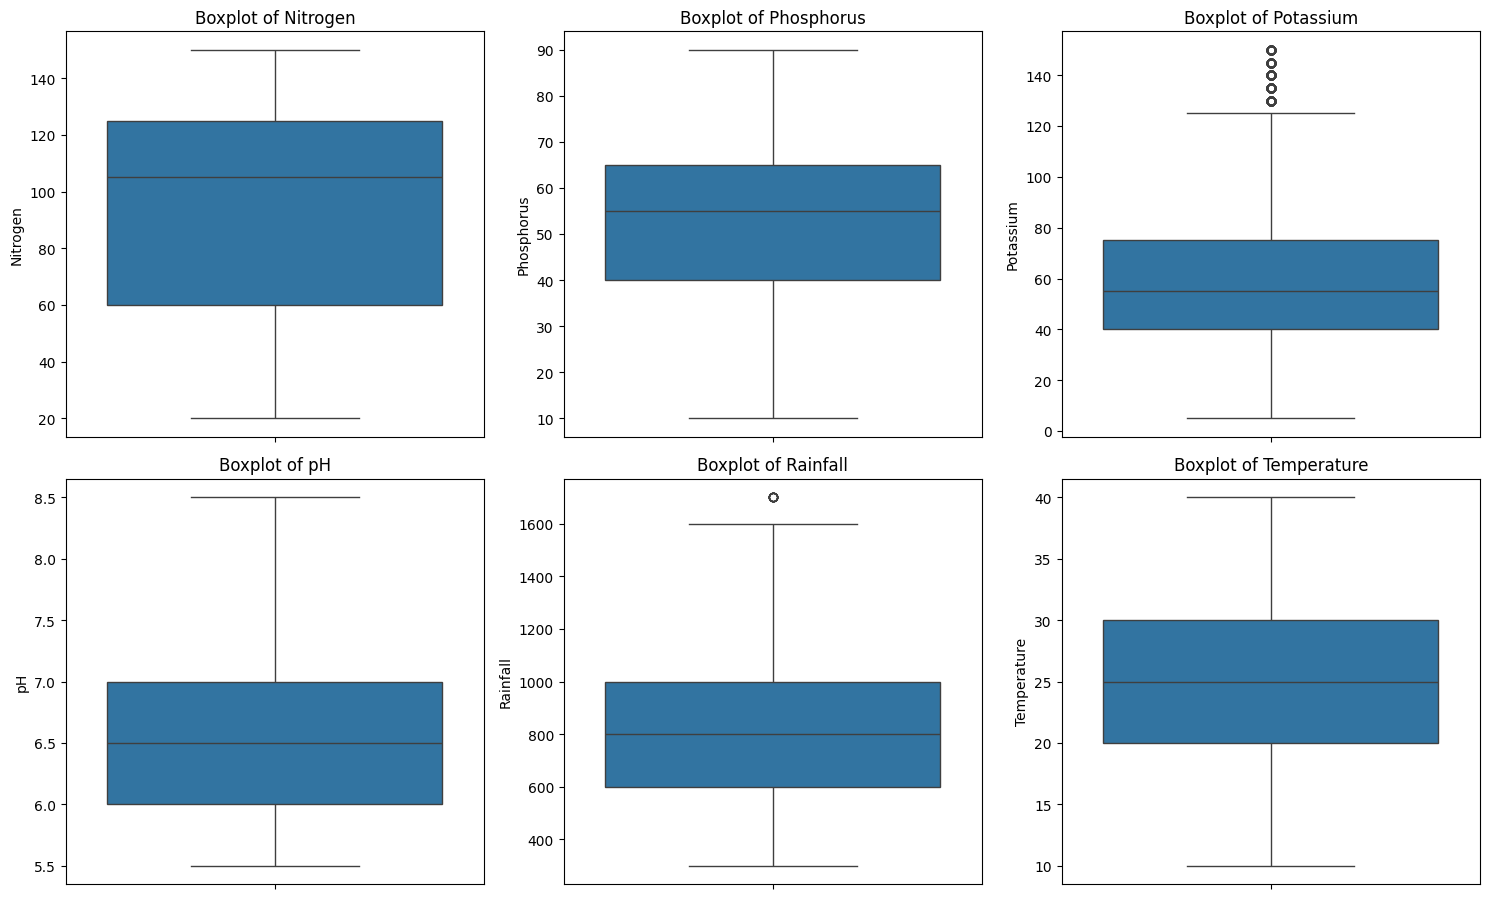

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 18)) # Adjust figure size for better readability
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1) # 4 rows, 3 columns for 12 numerical features
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [ ]:
# Identify numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print("\nOutlier Detection (using IQR method):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Column '{col}': {len(outliers)} outliers detected (outside [{lower_bound:.2f}, {upper_bound:.2f}])")
    if not outliers.empty:
        print("\tSample outliers:")
        display(outliers[[col]].head())


Outlier Detection (using IQR method):
Column 'Nitrogen': 0 outliers detected (outside [-37.50, 222.50])
Column 'Phosphorus': 0 outliers detected (outside [2.50, 102.50])
Column 'Potassium': 495 outliers detected (outside [-12.50, 127.50])
	Sample outliers:


,Potassium
2531,130
2532,130
2533,130
2534,130
2535,130


Column 'pH': 0 outliers detected (outside [4.50, 8.50])
Column 'Rainfall': 9 outliers detected (outside [0.00, 1600.00])
	Sample outliers:


,Rainfall
3895,1700
3896,1700
3897,1700
3904,1700
3905,1700


Column 'Temperature': 0 outliers detected (outside [5.00, 45.00])


In [ ]:
df.describe()

,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature
count,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000
mean,95.409927,54.341901,63.595170,6.715267,819.189010,25.915134
std,38.060648,16.551991,35.691911,0.625198,251.730813,5.897328
min,20.000000,10.000000,5.000000,5.500000,300.000000,10.000000
25%,60.000000,40.000000,40.000000,6.000000,600.000000,20.000000
50%,105.000000,55.000000,55.000000,6.500000,800.000000,25.000000
75%,125.000000,65.000000,75.000000,7.000000,1000.000000,30.000000
max,150.000000,90.000000,150.000000,8.500000,1700.000000,40.000000


## Data Visualization

### Distribution of Numerical Features

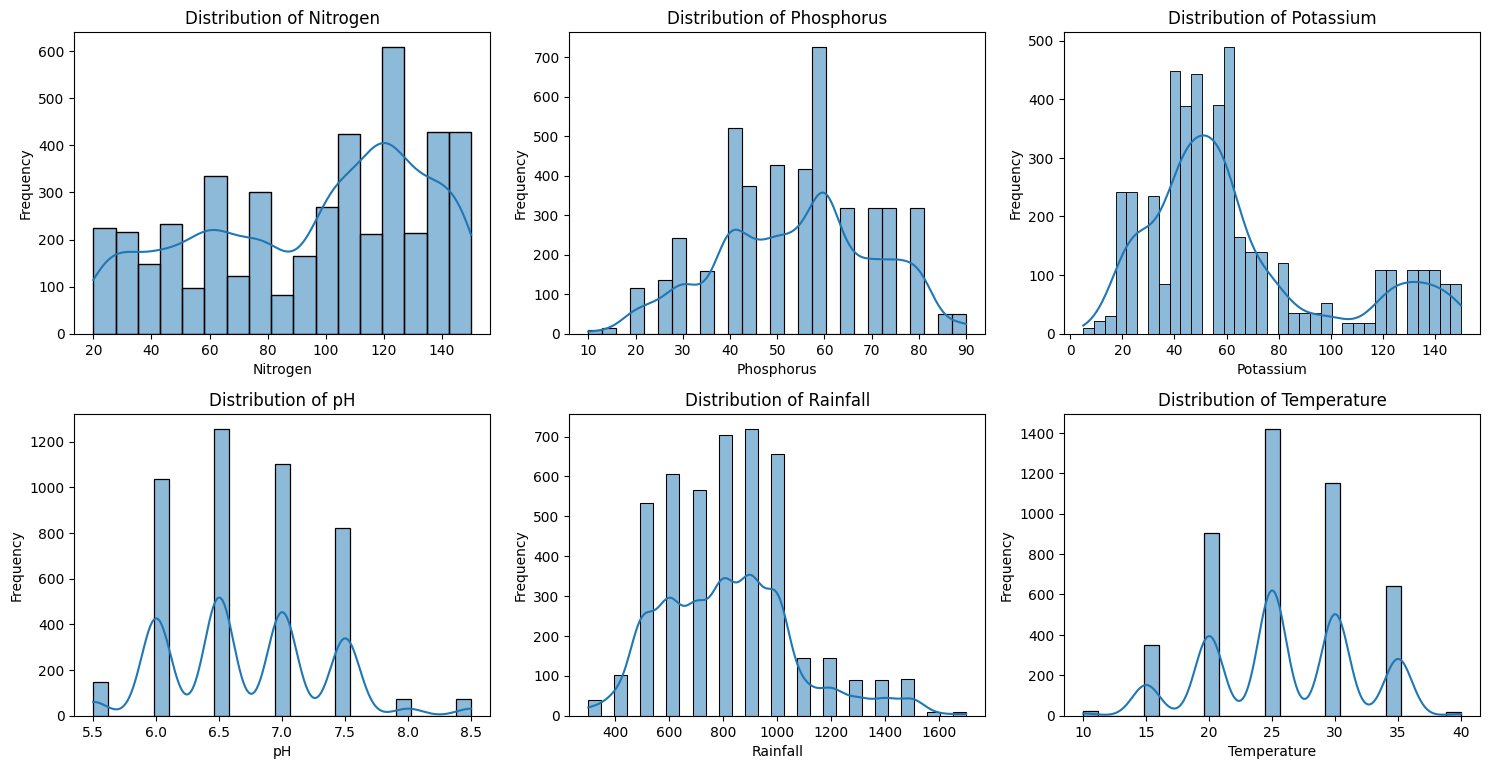

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 15)) # Increased figure height for more rows
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1) # Changed subplot grid to 4 rows, 3 columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Distribution of Categorical Features

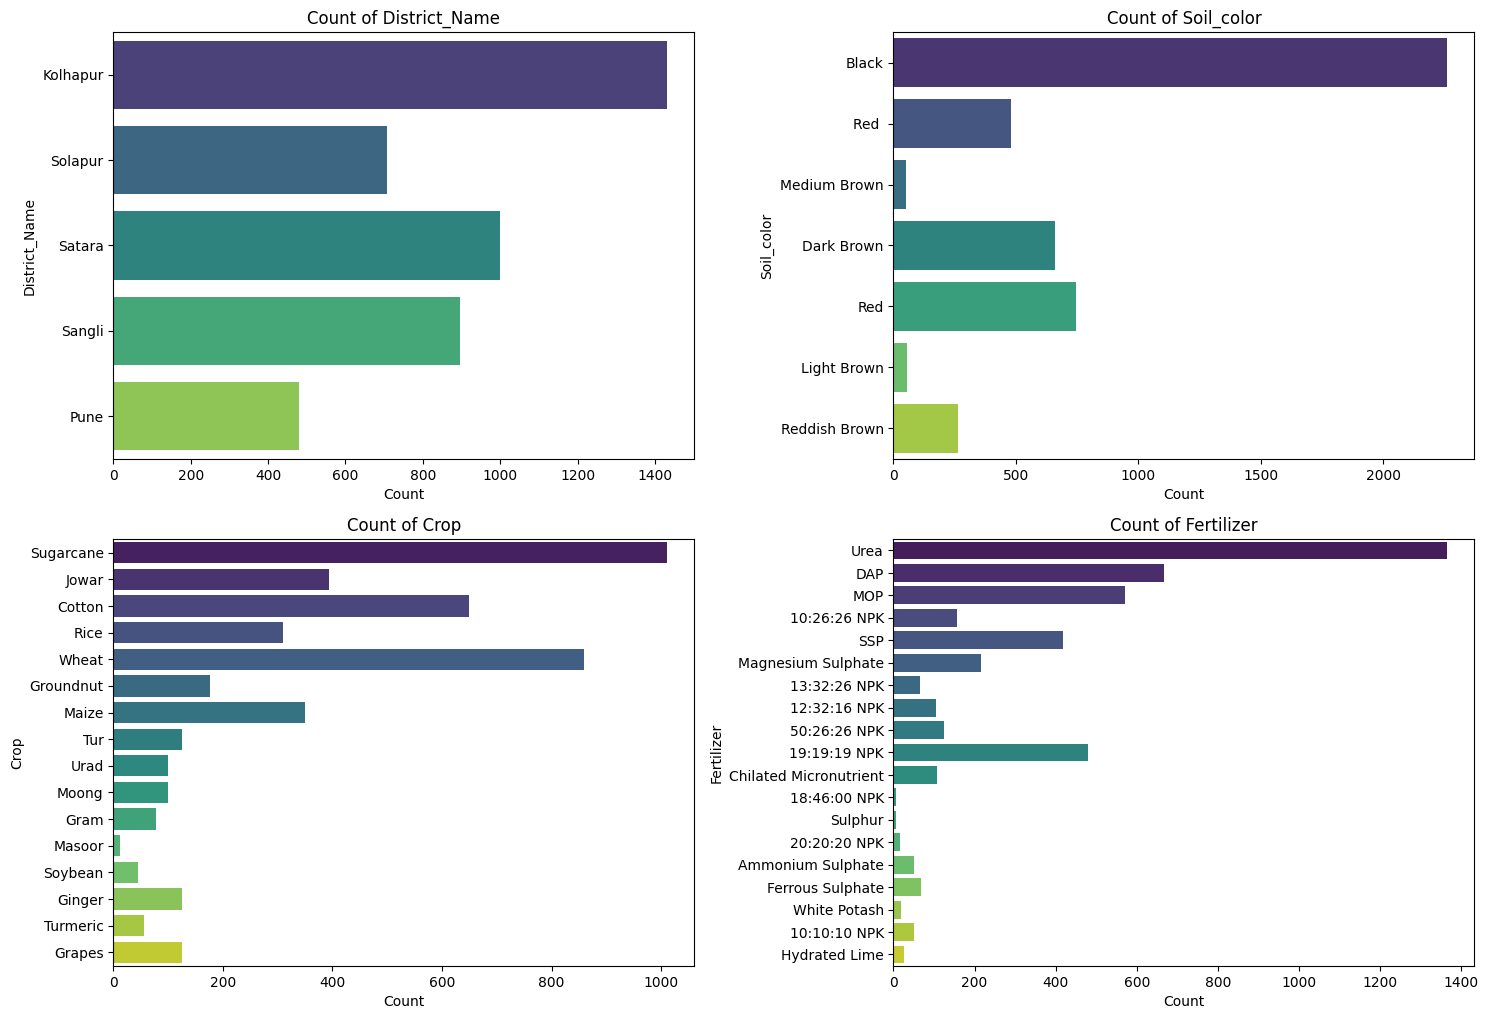

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

plt.figure(figsize=(15, 20)) # Increased figure height for more rows
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 2, i + 1) # Changed subplot grid to 4 rows, 2 columns
    sns.countplot(y=df[col], hue=df[col], palette='viridis', legend=False) # Addressed FutureWarning
    plt.title(f'Count of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

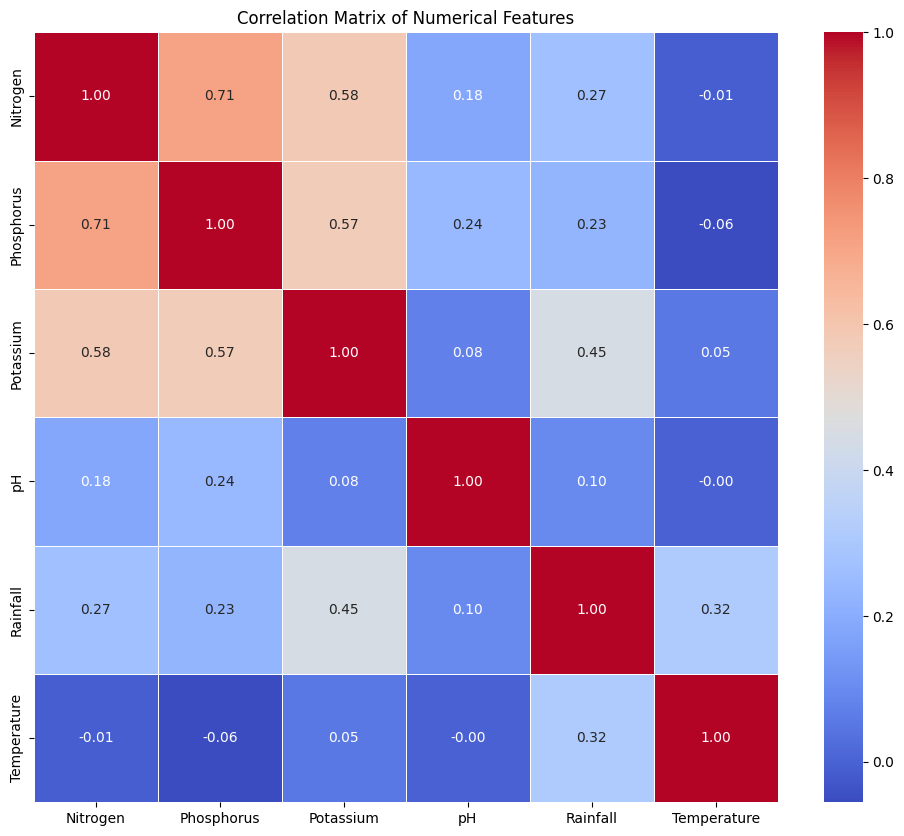

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Chi-Square Test for Categorical Features vs. Recommended_Fertilizer

In [ ]:
from scipy.stats import chi2_contingency

categorical_features = df.select_dtypes(include='object').columns.tolist()
if 'Fertilizer' in categorical_features:
    categorical_features.remove('Fertilizer')

print("Chi-Square Test Results:")
for feature in categorical_features:
    print(f"\n--- Feature: {feature} ---")
    contingency_table = pd.crosstab(df[feature], df['Fertilizer'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Degrees of freedom: {dof}")

    if p_value < 0.05:
        print("Conclusion: Reject the null hypothesis. There is a significant relationship between",feature,"and Fertilizer.")
    else:
        print("Conclusion: Fail to reject the null hypothesis. There is no significant relationship between",feature,"and Fertilizer.")

Chi-Square Test Results:

--- Feature: District_Name ---
Chi-square statistic: 1944.3662
P-value: 0.0000
Degrees of freedom: 72
Conclusion: Reject the null hypothesis. There is a significant relationship between District_Name and Fertilizer.

--- Feature: Soil_color ---
Chi-square statistic: 4757.1409
P-value: 0.0000
Degrees of freedom: 108
Conclusion: Reject the null hypothesis. There is a significant relationship between Soil_color and Fertilizer.

--- Feature: Crop ---
Chi-square statistic: 23558.6628
P-value: 0.0000
Degrees of freedom: 270
Conclusion: Reject the null hypothesis. There is a significant relationship between Crop and Fertilizer.


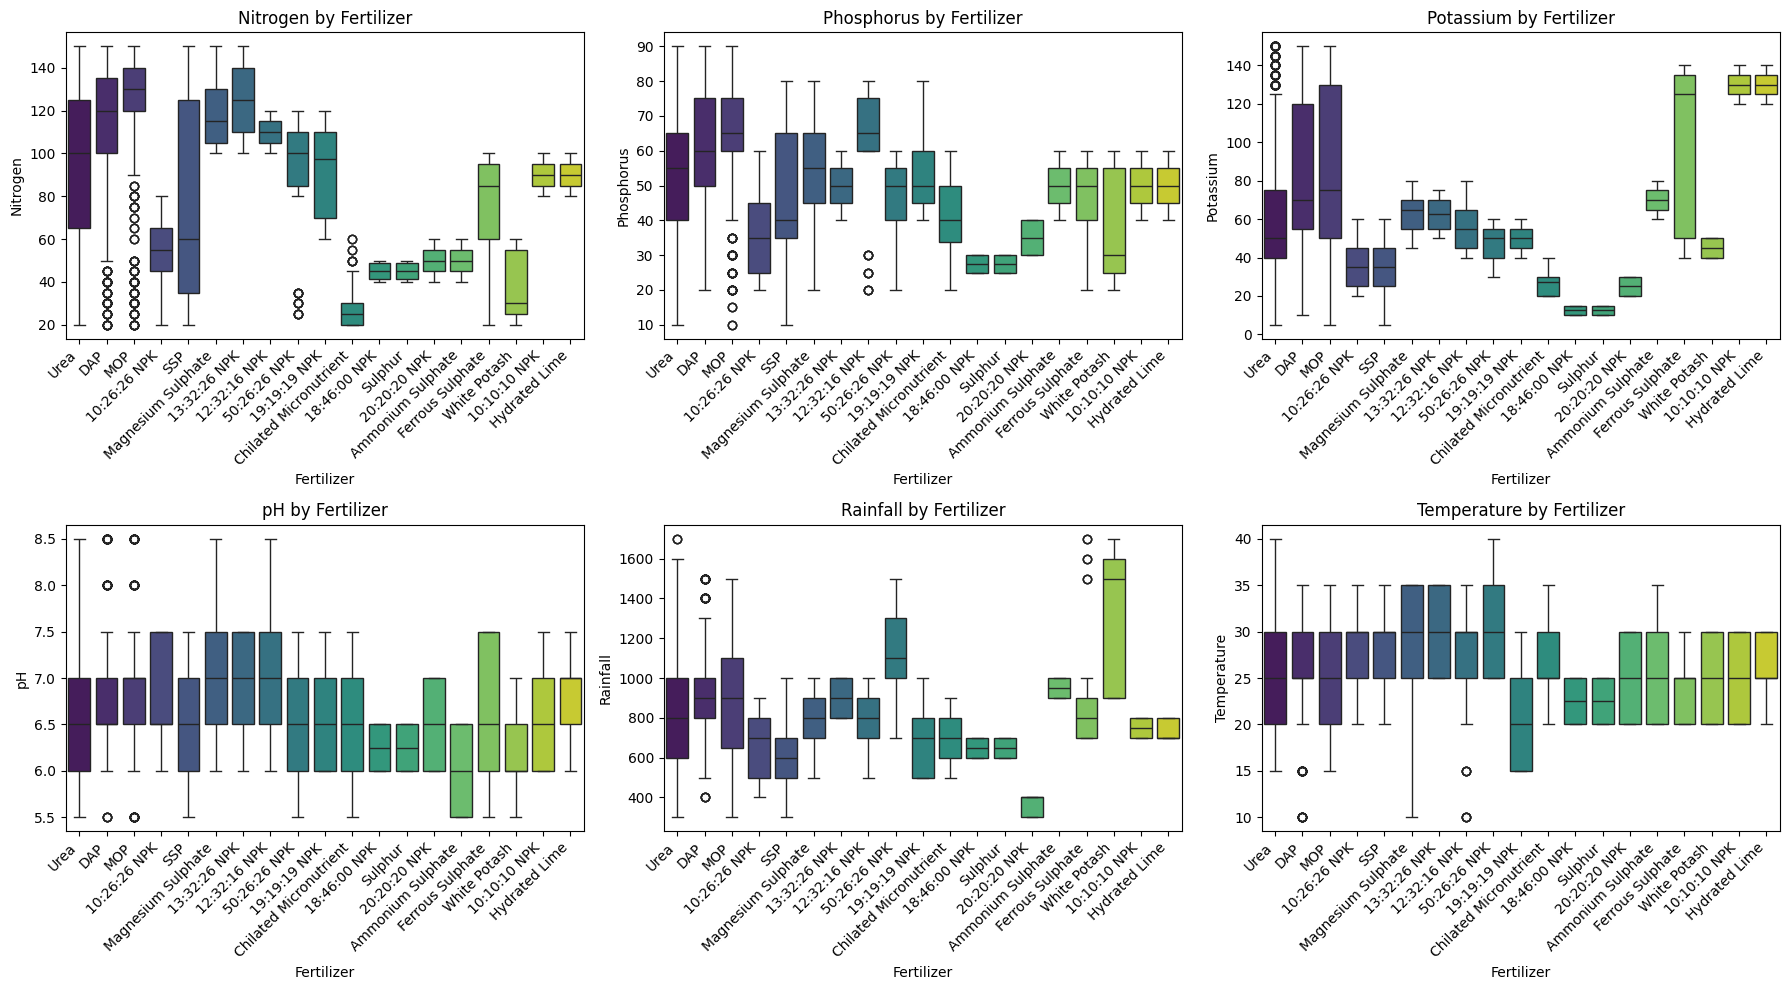

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Determine grid size for subplots dynamically
num_plots = len(numerical_cols)
n_cols = 3 # Let's try 3 columns for better layout
n_rows = (num_plots + n_cols - 1) // n_cols # Ceiling division

plt.figure(figsize=(18, 5 * n_rows)) # Adjust figure size for better readability

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x='Fertilizer', y=col, data=df, palette='viridis', hue='Fertilizer', legend=False)
    plt.title(f'{col} by Fertilizer')
    plt.xlabel('Fertilizer')
    plt.ylabel(col)
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability

plt.tight_layout()
plt.show()

# Persiapan Modeling
## Split Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================
# Feature & Target
# ==========================

X = df.drop("Fertilizer", axis=1)
y = df["Fertilizer"]

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Column identification
categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print(X_train.shape, X_test.shape)

(3610, 9) (903, 9)


## Random Forest

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

rf_model = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)

## XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

xgb_model = Pipeline([
    ("preprocessor", xgb_preprocessor),
    ("classifier", XGBClassifier(
        objective="multi:softprob",
        num_class=len(np.unique(y_train)),
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

In [ ]:
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)

## CatBoost

In [ ]:
from catboost import CatBoostClassifier

# posisi kolom kategorikal
cat_feature_idx = [
    X_train.columns.get_loc(col)
    for col in categorical_features
]

cat_model = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.03,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    random_seed=42,
    verbose=100
)

In [ ]:
cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_feature_idx
)

cat_pred = cat_model.predict(X_test)
cat_pred = cat_pred.astype(int).flatten()

cat_proba = cat_model.predict_proba(X_test)

0:	learn: 0.2836112	total: 1.07s	remaining: 17m 50s
100:	learn: 0.4995777	total: 1m 29s	remaining: 13m 13s
200:	learn: 0.5544053	total: 2m 46s	remaining: 11m
300:	learn: 0.6328836	total: 4m 7s	remaining: 9m 33s
400:	learn: 0.7750282	total: 5m 35s	remaining: 8m 20s
500:	learn: 0.8482434	total: 7m 5s	remaining: 7m 3s
600:	learn: 0.8867059	total: 8m 36s	remaining: 5m 42s
700:	learn: 0.9163852	total: 10m 6s	remaining: 4m 18s
800:	learn: 0.9381780	total: 11m 35s	remaining: 2m 52s
900:	learn: 0.9484629	total: 13m 6s	remaining: 1m 26s
999:	learn: 0.9556771	total: 14m 36s	remaining: 0us


## MLP

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

mlp_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

mlp_model = Pipeline([
    ("preprocessor", mlp_preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(128,64),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

In [ ]:
mlp_model.fit(X_train, y_train)

mlp_pred = mlp_model.predict(X_test)
mlp_proba = mlp_model.predict_proba(X_test)

# Evaluation

In [ ]:
from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_true, y_pred, y_proba):

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    auc = roc_auc_score(
        y_true,
        y_proba,
        multi_class="ovr",
        average="macro"
    )

    print(f"\n{name}")
    print("="*50)

    print(f"Macro F1 : {macro_f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=le.classes_,
            zero_division=0
        )
    )

    return macro_f1, auc

In [ ]:
rf_f1, rf_auc = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_proba
)

xgb_f1, xgb_auc = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_proba
)

cat_f1, cat_auc = evaluate_model(
    "CatBoost",
    y_test,
    cat_pred,
    cat_proba
)

mlp_f1, mlp_auc = evaluate_model(
    "MLP",
    y_test,
    mlp_pred,
    mlp_proba
)


Random Forest
Macro F1 : 0.9303
ROC AUC  : 0.9976
                        precision    recall  f1-score   support

          10:10:10 NPK       1.00      1.00      1.00        10
          10:26:26 NPK       0.82      0.87      0.84        31
          12:32:16 NPK       0.76      0.90      0.83        21
          13:32:26 NPK       1.00      1.00      1.00        13
          18:46:00 NPK       1.00      1.00      1.00         1
          19:19:19 NPK       0.96      0.99      0.97        96
          20:20:20 NPK       1.00      1.00      1.00         3
          50:26:26 NPK       0.96      0.96      0.96        25
     Ammonium Sulphate       0.91      1.00      0.95        10
Chilated Micronutrient       0.85      1.00      0.92        22
                   DAP       0.90      0.93      0.92       134
      Ferrous Sulphate       1.00      0.93      0.96        14
         Hydrated Lime       1.00      1.00      1.00         5
                   MOP       0.93      0.88      0.9

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "MLP": mlp_model
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y_encoded,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    print(f"\n{name}")
    print(f"Scores : {scores}")
    print(f"Mean   : {scores.mean():.4f}")
    print(f"Std    : {scores.std():.4f}")


Random Forest
Scores : [0.95484109 0.95768774 0.92875748 0.88683075 0.9428854 ]
Mean   : 0.9342
Std    : 0.0258

XGBoost
Scores : [0.87333798 0.87049876 0.84594533 0.94646333 0.90647361]
Mean   : 0.8885
Std    : 0.0348

MLP
Scores : [0.79711715 0.75120842 0.69773523 0.75832586 0.79047303]
Mean   : 0.7590
Std    : 0.0354
